# Supply Chain Routing: MILP vs Q-Learning Comparison

In [1]:
from pathlib import Path

from rl.train import run_all

if not Path("results/milp_global.csv").exists():
    run_all(episodes=15_000, num_milp_simulations=10)
else:
    print("Results already exist — loading from CSVs.")

Results already exist — loading from CSVs.


## Cost Comparison Table

In [2]:
import pandas as pd

milp_global = pd.read_csv("results/milp_global.csv")
milp_daily = pd.read_csv("results/milp_daily.csv")
rl = pd.read_csv("results/rl_policy.csv")

milp_opt = milp_global["total_cost"].iloc[0]
daily_mean = milp_daily["total_cost"].mean()
daily_std = milp_daily["total_cost"].std()
rl_mean = rl["total_cost"].mean()
rl_std = rl["total_cost"].std()

summary = pd.DataFrame([
    {"Method": "MILP Global (optimal)", "Mean Cost ($)": f"{milp_opt:,.0f}", "Std ($)": "--", "Gap vs Optimal": "--"},
    {"Method": "MILP Daily Myopic",     "Mean Cost ($)": f"{daily_mean:,.0f}", "Std ($)": f"{daily_std:,.0f}", "Gap vs Optimal": f"{(daily_mean/milp_opt - 1)*100:.1f}%"},
    {"Method": "Q-Learning",            "Mean Cost ($)": f"{rl_mean:,.0f}",    "Std ($)": f"{rl_std:,.0f}",    "Gap vs Optimal": f"{(rl_mean/milp_opt - 1)*100:.1f}%"},
])
summary.set_index("Method")

,Mean Cost ($),Std ($),Gap vs Optimal
Method,,,
MILP Global (optimal),"17,020",--,--
MILP Daily Myopic,"19,519",231,14.7%
Q-Learning,"28,715","99,811",68.7%


## Learning Curve

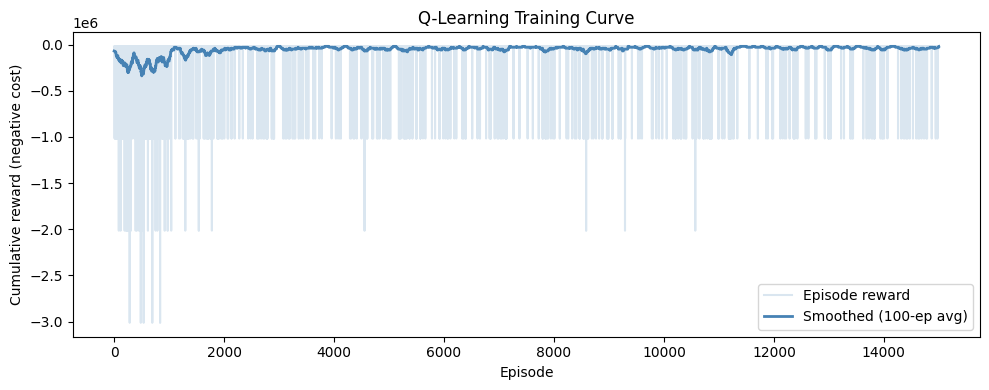

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

lc = pd.read_csv("results/learning_curve.csv")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lc["episode"], lc["episode_reward"], alpha=0.2, color="steelblue", label="Episode reward")
ax.plot(lc["episode"], lc["smoothed_reward"], color="steelblue", linewidth=2, label="Smoothed (100-ep avg)")
ax.set_xlabel("Episode")
ax.set_ylabel("Cumulative reward (negative cost)")
ax.set_title("Q-Learning Training Curve")
ax.legend()
plt.tight_layout()
plt.show()

## Learned Policy Table

In [4]:
import pandas as pd

policy = pd.read_csv("results/rl_policy_table.csv")
policy["demand_label"] = policy["demand_bucket"].map({0: "Low", 1: "Med", 2: "High"})
pivot = policy.pivot(index="day", columns="demand_label", values="open_dcs")
print("Learned DC policy: open_dcs per (day, demand level)")
pivot

Learned DC policy: open_dcs per (day, demand level)


demand_label,High,Low,Med
day,,,
0,[3],"[0, 2]",[3]
1,"[0, 1, 2, 3]","[0, 2]","[0, 1, 3]"
2,[],[0],[]
3,[],[],[]
4,"[1, 2, 3]",[2],"[1, 3]"
5,"[0, 3]","[3, 4]","[1, 2, 4]"
6,"[2, 3, 4]","[2, 4]","[2, 4]"
7,"[0, 2, 3]","[0, 1, 4]","[0, 4]"
8,[4],"[0, 2, 3]","[0, 4]"


## cuOpt Experiment: OR-Tools VRP Baseline Results

Replaces the LP flow sub-solver with a proper CVRPTW solver (OR-Tools Routing Library).
cuOpt GPU comparison pending WSL2 CUDA setup (see issue #6).

**OR-Tools VRP benchmark:** 12–500 customers, single DC, n_vehicles = ceil(n/8).
**RL training:** 5000 episodes using OR-Tools VRP sub-solver.

=== OR-Tools VRP Benchmark ===
 n_customers  n_vehicles      solver  solve_time_s  total_cost
          12           2 ortools_vrp      0.015599     126.864
          50           7 ortools_vrp      0.123574     554.612
         100          13 ortools_vrp      0.498636    1154.234
         250          32 ortools_vrp      3.124535    2728.396
         500          63 ortools_vrp     10.057079    5482.346


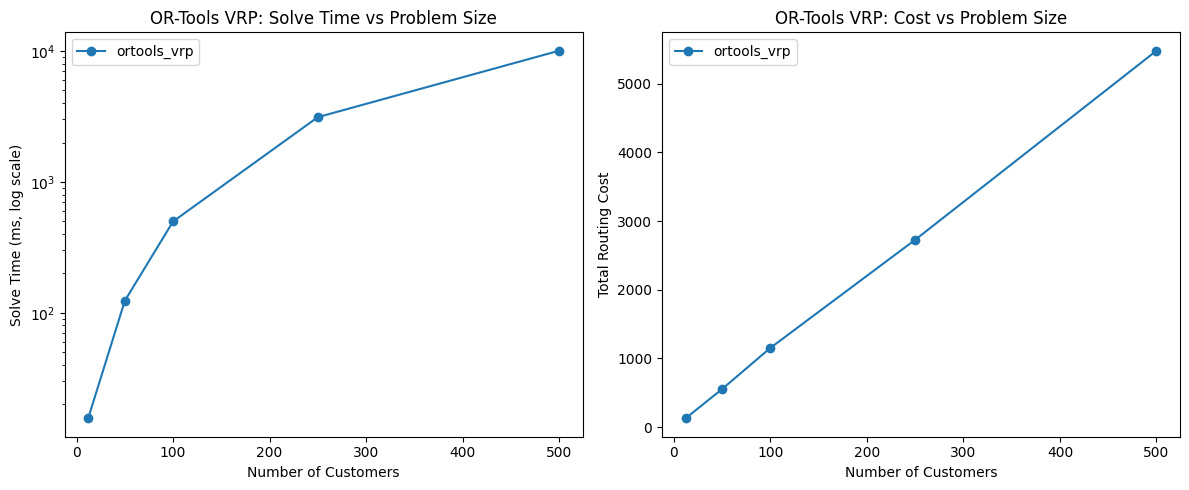

Chart saved to results/benchmark_chart.png


In [5]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Benchmark: solve time vs problem size ---
benchmark_path = Path("results/cuopt_benchmark.csv")
if benchmark_path.exists():
    df = pd.read_csv(benchmark_path)
    print("=== OR-Tools VRP Benchmark ===")
    print(df.to_string(index=False))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    for solver in df["solver"].unique():
        sub = df[df["solver"] == solver].sort_values("n_customers")
        ax1.plot(sub["n_customers"], sub["solve_time_s"] * 1000, marker="o", label=solver)
    ax1.set_xlabel("Number of Customers")
    ax1.set_ylabel("Solve Time (ms, log scale)")
    ax1.set_title("OR-Tools VRP: Solve Time vs Problem Size")
    ax1.set_yscale("log")
    ax1.legend()

    for solver in df["solver"].unique():
        sub = df[df["solver"] == solver].sort_values("n_customers")
        ax2.plot(sub["n_customers"], sub["total_cost"], marker="o", label=solver)
    ax2.set_xlabel("Number of Customers")
    ax2.set_ylabel("Total Routing Cost")
    ax2.set_title("OR-Tools VRP: Cost vs Problem Size")
    ax2.legend()

    plt.tight_layout()
    plt.savefig("results/benchmark_chart.png", dpi=150)
    plt.show()
    print("Chart saved to results/benchmark_chart.png")
else:
    print("Run: uv run python -m rl.benchmark")

=== RL Policy Eval Cost by Sub-Solver ===
            mean       std
solver                    
ortools  42364.0  197979.0


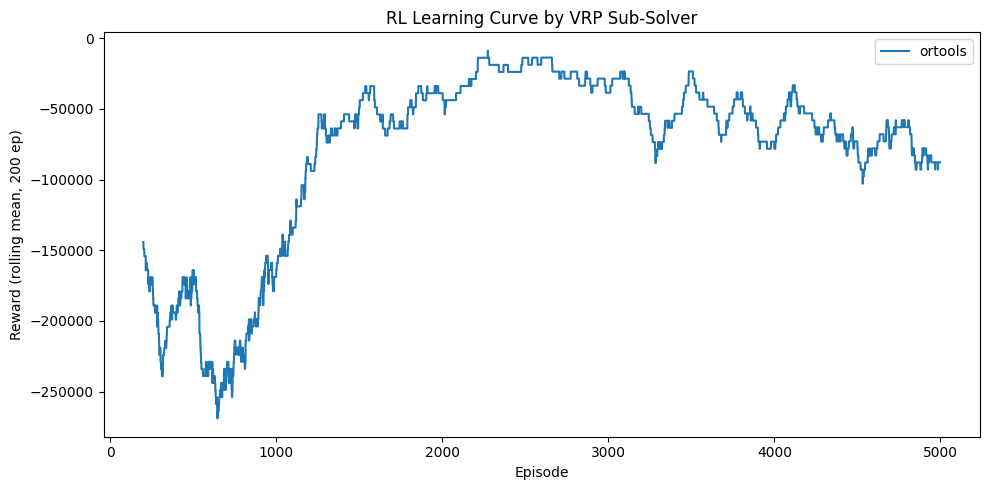

In [6]:
# --- RL training results ---
import glob
import pandas as pd
import matplotlib.pyplot as plt

rl_files = [f for f in glob.glob("results/rl_vrp_*.csv") if "curve" not in f]
if rl_files:
    rl_dfs = []
    for f in rl_files:
        solver_name = f.replace("results/rl_vrp_", "").replace(".csv", "")
        d = pd.read_csv(f)
        d["solver"] = solver_name
        rl_dfs.append(d)
    rl_df = pd.concat(rl_dfs)
    summary = rl_df.groupby("solver")["total_cost"].agg(["mean", "std"]).round(0)
    print("=== RL Policy Eval Cost by Sub-Solver ===")
    print(summary.to_string())

    # Learning curves
    curve_files = glob.glob("results/rl_vrp_*_curve.csv")
    if curve_files:
        fig, ax = plt.subplots(figsize=(10, 5))
        for cf in curve_files:
            solver_name = cf.replace("results/rl_vrp_", "").replace("_curve.csv", "")
            curve_df = pd.read_csv(cf)
            # Smooth with rolling mean
            smoothed = curve_df.iloc[:, 1].rolling(200).mean()
            ax.plot(smoothed.values, label=solver_name)
        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward (rolling mean, 200 ep)")
        ax.set_title("RL Learning Curve by VRP Sub-Solver")
        ax.legend()
        plt.tight_layout()
        plt.savefig("results/rl_vrp_learning_curve.png", dpi=150)
        plt.show()
else:
    print("Run: uv run python -m rl.train_vrp --solver ortools --episodes 5000")